# Эксперимент 18 v2: SSL Domain Adaptation (SimCLR, исправленный batch)

## Что было не так в v1

SimCLR с **batch=2** имеет только 2 негативных образца на пару. NT-Xent достигает теоретического
минимума (≈0.239 при T=0.5) уже к эпохе 7–8 и дальше не улучшается — дно исчерпано.

| Версия | batch SSL | Негативов/пару | SSL epochs | Теор. минимум | Факт. loss |
|---|---|---|---|---|---|
| v1 | 2 | 2 | 15 | ~0.239 | ~0.253 (плато с эп.7) |
| **v2** | **4** | **6** | **30** | **~0.103** | ? |

## Изменения
1. `SSL_BATCH_SIZE` **2 → 4** (6 негативов vs 2, 3× больше разнообразия)
2. `SSL_EPOCHS` **15 → 30** (теперь есть куда сходиться)
3. Более сильные аугментации: добавлен Gaussian blur, усилен ColorJitter
4. Виды обрабатываются **отдельно** (batch=4 через backbone) — безопасно для 8.5 Гб VRAM
5. Fine-tuning: точный пайплайн Эксп.17

## 1. Импорты и конфигурация

In [1]:
import os, random, json, pickle, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchmetrics import JaccardIndex
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

print(f'PyTorch: {torch.__version__}')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} Гб')

DATA_DIR      = 'D:/VKR/VKR/DATA_DIR/'
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')
TRAIN_IMG_DIR = os.path.join(DATA_DIR, 'train_images/')
save_dir      = 'D:/VKR/VKR/dino_heads'
os.makedirs(save_dir, exist_ok=True)

# ── Архитектура ───────────────────────────────────────────────────────
IMG_H       = 224
IMG_W       = 1400
PATCH_SIZE  = 14
PATCH_H     = IMG_H // PATCH_SIZE   # 16
PATCH_W     = IMG_W // PATCH_SIZE   # 100
MASK_H      = PATCH_H * 4          # 64
MASK_W      = PATCH_W * 4          # 400
EMBED_DIM   = 768
NUM_CLASSES = 5
INTERMEDIATE_LAYERS = [3, 5, 8, 11]

# ── Данные (Эксп.13) ──────────────────────────────────────────────────
N_PER_CLASS  = 200
TEST_SIZE    = 0.2
SYNTH_WEIGHT = 0.5

# ── Fine-tuning (Эксп.16/17) ──────────────────────────────────────────
N_UNFREEZE   = 4
LR_BACKBONE  = 1e-5
LR_DECAY     = 0.75
LR_HEAD      = 1e-3
BATCH_SIZE   = 4
EPOCHS       = 75
FLIP_P       = 0.5
CROP_SCALE   = (0.85, 1.0)
BRIGHTNESS   = 0.3
USE_AMP      = (DEVICE == 'cuda')

# ── SSL (v2: исправленный batch) ──────────────────────────────────────
SSL_BATCH_SIZE  = 4     # БЫЛО 2 → теперь 6 негативов на пару (было 2)
SSL_EPOCHS      = 30    # БЫЛО 15 → теперь есть куда сходиться
SSL_LR_BACKBONE = 1e-5
SSL_LR_PROJ     = 1e-3
SSL_TEMPERATURE = 0.5
SSL_PROJ_DIM    = 128
SSL_SAVE_LABEL  = 'exp18v2'

print(f'\nSSL batch: {SSL_BATCH_SIZE}  (негативов на пару: {SSL_BATCH_SIZE*2-2})')
print(f'SSL epochs: {SSL_EPOCHS}')
print(f'Fine-tune batch: {BATCH_SIZE} | AMP: {USE_AMP}')

PyTorch: 2.12.0.dev20260408+cu128
Устройство: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
VRAM: 8.5 Гб

SSL batch: 4  (негативов на пару: 6)
SSL epochs: 30
Fine-tune batch: 4 | AMP: True


## 2. Загрузка данных

In [2]:
train_df    = pd.read_csv(TRAIN_CSV)
labeled_ids = train_df['ImageId'].unique().tolist()
print(f'Строк: {len(train_df):,}  |  Размеченных изображений: {len(labeled_ids):,}')

# Все изображения в папке (включая фоновые без аннотаций) — для SSL
all_train_imgs = sorted([f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith('.jpg')])
print(f'Всего изображений в train_images: {len(all_train_imgs):,}  (используем для SSL)')


def decode_rle(rle_string, shape=(256, 1600)):
    if pd.isna(rle_string) or not isinstance(rle_string, str):
        return np.zeros(shape, dtype=np.uint8)
    nums   = list(map(int, rle_string.strip().split()))
    starts = np.array(nums[0::2]) - 1
    lens   = np.array(nums[1::2])
    mask   = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for s, l in zip(starts, lens):
        mask[s:s+l] = 1
    return mask.reshape(shape, order='F')


def build_segmask(image_id, df, shape=(256, 1600)):
    mask = np.zeros(shape, dtype=np.uint8)
    for _, row in df[df['ImageId'] == image_id].iterrows():
        cls = int(row['ClassId'])
        m   = decode_rle(row['EncodedPixels'], shape)
        mask[m == 1] = cls
    return mask


def compute_class_weights(image_ids, df, num_classes=NUM_CLASSES):
    px = Counter({c: 0 for c in range(num_classes)})
    for img_id in image_ids:
        mask = build_segmask(img_id, df)
        for c in range(num_classes):
            px[c] += int((mask == c).sum())
    total = sum(px.values())
    w = torch.tensor([total/(num_classes*(px[c]+1e-6)) for c in range(num_classes)])
    w = (w / w.mean()).clamp(min=0.1, max=5.0)
    for c, v in enumerate(w):
        print(f'  {"Фон" if c==0 else f"Дефект {c}"}: {v:.3f}  ({px[c]:,} пикс.)')
    return w.to(DEVICE)


classes_cache = train_df.groupby('ImageId')['ClassId'].apply(
    lambda x: sorted(x.dropna().astype(int).unique().tolist())
).to_dict()
label_map = {img_id: (cls_list[0] if cls_list else 0)
             for img_id, cls_list in classes_cache.items()}

print('Вспомогательные функции определены.')

Строк: 7,095  |  Размеченных изображений: 6,666
Всего изображений в train_images: 12,568  (используем для SSL)
Вспомогательные функции определены.


## 3. Dataset (fine-tuning)

In [3]:
class JointTransform:
    def __init__(self, img_h=IMG_H, img_w=IMG_W, is_train=True,
                 flip_p=FLIP_P, crop_scale=CROP_SCALE, brightness=BRIGHTNESS):
        self.img_h        = img_h
        self.img_w        = img_w
        self.is_train     = is_train
        self.flip_p       = flip_p
        self.crop_scale   = crop_scale
        self.color_jitter = transforms.ColorJitter(brightness=brightness)
        self.to_tensor    = transforms.ToTensor()
        self.normalize    = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil, mask_np):
        img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        mask_pil = Image.fromarray(mask_np).resize(
            (self.img_w, self.img_h), Image.NEAREST)
        if self.is_train:
            if random.random() < self.flip_p:
                img_pil  = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
                mask_pil = mask_pil.transpose(Image.FLIP_LEFT_RIGHT)
            scale  = random.uniform(*self.crop_scale)
            crop_h = max(1, int(self.img_h * scale))
            crop_w = max(1, int(self.img_w * scale))
            top    = random.randint(0, self.img_h - crop_h)
            left   = random.randint(0, self.img_w - crop_w)
            img_pil  = img_pil.crop((left, top, left+crop_w, top+crop_h))
            mask_pil = mask_pil.crop((left, top, left+crop_w, top+crop_h))
            img_pil  = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
            mask_pil = mask_pil.resize((self.img_w, self.img_h), Image.NEAREST)
            img_pil  = self.color_jitter(img_pil)
        img_t    = self.normalize(self.to_tensor(img_pil))
        mask_np2 = np.array(mask_pil, dtype=np.uint8)
        return img_t, mask_np2


class SteelSegDataset(Dataset):
    def __init__(self, ids, img_dir, df, joint_transform):
        self.ids=ids; self.img_dir=img_dir; self.df=df; self.jt=joint_transform
    def __len__(self): return len(self.ids)
    def __getitem__(self, idx):
        img_id = self.ids[idx]
        img    = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
        mask   = build_segmask(img_id, self.df)
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, 0


class SteelSegDatasetWithSynth(Dataset):
    def __init__(self, real_ids, img_dir, df, joint_transform, synth_pairs):
        self.real_ids = real_ids; self.img_dir = img_dir; self.df = df
        self.jt = joint_transform; self.synth = synth_pairs
        self.n_real = len(real_ids); self.n_synth = len(synth_pairs)
    def __len__(self): return self.n_real + self.n_synth
    def __getitem__(self, idx):
        if idx < self.n_real:
            img_id   = self.real_ids[idx]
            img      = Image.open(os.path.join(self.img_dir, img_id)).convert('RGB')
            mask     = build_segmask(img_id, self.df)
            is_synth = 0
        else:
            img_np, mask = self.synth[idx - self.n_real]
            img          = Image.fromarray(img_np.astype(np.uint8))
            is_synth     = 1
        img_t, mask_np = self.jt(img, mask)
        mask_t = torch.from_numpy(mask_np).unsqueeze(0).float()
        mask_t = F.interpolate(
            mask_t.unsqueeze(0), size=(MASK_H, MASK_W),
            mode='nearest').squeeze().long()
        return img_t, mask_t, is_synth


train_jt = JointTransform(is_train=True)
val_jt   = JointTransform(is_train=False)
print('Datasets определены.')

Datasets определены.


## 4. Загрузка DINOv2

In [4]:
dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14',
                        pretrained=True, verbose=False)
dinov2 = dinov2.to(DEVICE)
for p in dinov2.parameters():
    p.requires_grad = False

n_blocks      = len(dinov2.blocks)        # 12
unfreeze_from = n_blocks - N_UNFREEZE     # 8
for i, block in enumerate(dinov2.blocks):
    if i >= unfreeze_from:
        for p in block.parameters():
            p.requires_grad = True
for p in dinov2.norm.parameters():
    p.requires_grad = True

frozen    = sum(p.numel() for p in dinov2.parameters() if not p.requires_grad)
trainable = sum(p.numel() for p in dinov2.parameters() if p.requires_grad)
print(f'DINOv2 ViT-B/14: {(frozen+trainable)/1e6:.1f}М параметров')
print(f'  Заморожено:  {frozen/1e6:.1f}М  (блоки 0–{unfreeze_from-1})')
print(f'  Разморожено: {trainable/1e6:.1f}М  (блоки {unfreeze_from}–{n_blocks-1} + norm)')

with torch.no_grad():
    test_img = torch.randn(1, 3, IMG_H, IMG_W).to(DEVICE)
    feats = dinov2.get_intermediate_layers(
        test_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
    assert all(f.shape == (1, PATCH_H*PATCH_W, EMBED_DIM) for f in feats)
    print(f'Forward OK: {len(feats)} слоёв × {feats[0].shape}')
del test_img, feats

if torch.cuda.is_available():
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM свободно: {free/1e9:.1f} / {total/1e9:.1f} Гб')

C:\Users\MSI Katana 17/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\MSI Katana 17/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\MSI Katana 17/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 ViT-B/14: 86.6М параметров
  Заморожено:  58.2М  (блоки 0–7)
  Разморожено: 28.4М  (блоки 8–11 + norm)
Forward OK: 4 слоёв × torch.Size([1, 1600, 768])
VRAM свободно: 6.8 / 8.5 Гб


## 5. Эмбеддинги (из кэша)

In [5]:
emb_cache = os.path.join(save_dir, 'embeddings.pt')
print('Загружаем из кэша...')
ckpt       = torch.load(emb_cache, map_location='cpu')
embeddings = ckpt['embeddings']
emb_ids    = ckpt['emb_ids']
emb_id_to_idx = {v: k for k, v in enumerate(emb_ids)}
print(f'Загружено: {embeddings.shape}')

Загружаем из кэша...
Загружено: torch.Size([6666, 768])


## 6. KMeans-отбор (200 на класс → ~778 реальных)

In [6]:
all_labels = [label_map.get(i, 0) for i in labeled_ids]
train_ids, test_ids = train_test_split(
    labeled_ids, test_size=TEST_SIZE, stratify=all_labels, random_state=SEED)
print(f'Train pool: {len(train_ids):,}  |  Test: {len(test_ids):,}')


def kmeans_select(embeddings, image_ids, n_select, seed=SEED):
    km = KMeans(n_clusters=n_select, random_state=seed, n_init=10)
    km.fit(embeddings.numpy())
    selected = []
    for k in range(n_select):
        m = km.labels_ == k
        if not m.any(): continue
        center  = torch.tensor(km.cluster_centers_[k])
        ix      = np.where(m)[0]
        nearest = int(ix[torch.norm(embeddings[m] - center, dim=1).argmin().item()])
        selected.append(image_ids[nearest])
    return selected


def select_per_class(embeddings, image_ids, classes_cache,
                     n_per_class=N_PER_CLASS, seed=SEED):
    image_id_to_idx = {v: k for k, v in enumerate(image_ids)}
    selected_set    = set()
    for cls in [1, 2, 3, 4]:
        cls_ids = [i for i in image_ids if cls in classes_cache.get(i, [])]
        n_avail = len(cls_ids)
        if n_avail == 0: continue
        if n_avail <= n_per_class:
            chosen = cls_ids
            print(f'  Класс {cls}: {n_avail} доступно → берём все')
        else:
            idxs       = [image_id_to_idx[i] for i in cls_ids]
            cls_embeds = embeddings[idxs]
            chosen     = kmeans_select(cls_embeds, cls_ids, n_per_class, seed)
            print(f'  Класс {cls}: {n_avail} → {len(chosen)} (KMeans)')
        selected_set.update(chosen)
    result = list(selected_set)
    print(f'Итого уникальных: {len(result)}')
    return result


pool_mask   = [emb_id_to_idx[i] for i in train_ids]
pool_embeds = embeddings[pool_mask]
print('Отбор 200 изображений на класс:')
selected_ids = select_per_class(pool_embeds, train_ids, classes_cache)
assert len(set(selected_ids) & set(test_ids)) == 0, 'Пересечение с тест-сетом!'
print('Пересечений с тест-сетом: 0 ✓')

Train pool: 5,332  |  Test: 1,334
Отбор 200 изображений на класс:
  Класс 1: 717 → 200 (KMeans)
  Класс 2: 197 доступно → берём все
  Класс 3: 4113 → 200 (KMeans)
  Класс 4: 641 → 200 (KMeans)
Итого уникальных: 778
Пересечений с тест-сетом: 0 ✓


## 7. Архитектура: SegHeadDPT + Lovász-Softmax

In [7]:
class SegHeadDPT(nn.Module):
    def __init__(self, embed_dim=EMBED_DIM, num_classes=NUM_CLASSES,
                 patch_h=PATCH_H, patch_w=PATCH_W, n_layers=4):
        super().__init__()
        self.patch_h  = patch_h
        self.patch_w  = patch_w
        self.n_layers = n_layers
        self.proj = nn.ModuleList([
            nn.Sequential(nn.Conv2d(embed_dim, 256, 1),
                          nn.BatchNorm2d(256), nn.GELU())
            for _ in range(n_layers)
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(256 * n_layers, 512, 1), nn.BatchNorm2d(512), nn.GELU(),
            nn.Conv2d(512, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU())
        self.up1 = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU())
        self.up2 = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 2, stride=2), nn.BatchNorm2d(64), nn.GELU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU())
        self.head = nn.Conv2d(64, num_classes, 1)

    def forward(self, features):
        maps = []
        for i, f in enumerate(features):
            B, N, C = f.shape
            x = f.reshape(B, self.patch_h, self.patch_w, C).permute(0,3,1,2)
            maps.append(self.proj[i](x))
        x = self.fuse(torch.cat(maps, dim=1))
        return self.head(self.up2(self.up1(x)))


def _lovász_grad(gt_sorted):
    n   = len(gt_sorted)
    gts = gt_sorted.sum()
    intersection = gts - gt_sorted.float().cumsum(0)
    union        = gts + (1.0 - gt_sorted).float().cumsum(0)
    jaccard      = 1.0 - intersection / union
    if n > 1:
        jaccard[1:] = jaccard[1:] - jaccard[:-1]
    return jaccard


def _lovász_softmax_flat(probas, labels):
    C = probas.size(1)
    losses = []
    for c in range(C):
        fg = (labels == c).float()
        if fg.sum() == 0: continue
        errors = (fg - probas[:, c]).abs()
        errors_sorted, perm = torch.sort(errors, descending=True)
        losses.append(torch.dot(errors_sorted, _lovász_grad(fg[perm])))
    return torch.stack(losses).mean() if losses else probas.sum() * 0.0


class LovászSoftmax(nn.Module):
    def forward(self, logits, targets):
        B, C, H, W = logits.shape
        probas  = F.softmax(logits.float(), dim=1).permute(0,2,3,1).reshape(-1, C)
        targets = targets.reshape(-1)
        return _lovász_softmax_flat(probas, targets)


_h = SegHeadDPT().to(DEVICE)
print(f'SegHeadDPT: {sum(p.numel() for p in _h.parameters()):,} параметров')
del _h

SegHeadDPT: 2,845,381 параметров


## 8. Синтетика (кэш Эксп.13)

In [8]:
synth_cache = os.path.join(save_dir, 'synth_pairs_exp13.pkl')
print('Загружаем синтетику...')
with open(synth_cache, 'rb') as f:
    synth_pairs = pickle.load(f)
print(f'Загружено: {len(synth_pairs)} пар  |  Итого: {len(selected_ids)+len(synth_pairs)}')

Загружаем синтетику...
Загружено: 2269 пар  |  Итого: 3047


## 9. Layer-wise LR decay

In [9]:
def make_backbone_param_groups(model, base_lr=LR_BACKBONE, decay=LR_DECAY,
                                n_unfreeze=N_UNFREEZE, weight_decay=1e-2):
    nb = len(model.blocks)
    unfreeze_from = nb - n_unfreeze
    groups = []
    norm_params = [p for p in model.norm.parameters() if p.requires_grad]
    if norm_params:
        groups.append({'params': norm_params, 'lr': base_lr,
                       'weight_decay': weight_decay, 'name': 'norm'})
    for i in range(nb - 1, unfreeze_from - 1, -1):
        block_params = [p for p in model.blocks[i].parameters() if p.requires_grad]
        if not block_params: continue
        depth = nb - 1 - i
        lr_i  = base_lr * (decay ** depth)
        groups.append({'params': block_params, 'lr': lr_i,
                       'weight_decay': weight_decay, 'name': f'block_{i}'})
    return groups


print('Layer-wise LR (fine-tuning):')
for g in make_backbone_param_groups(dinov2):
    n_p = sum(p.numel() for p in g['params'])
    print(f'  {g["name"]:<10}  LR={g["lr"]:.2e}  params={n_p/1e6:.2f}М')

Layer-wise LR (fine-tuning):
  norm        LR=1.00e-05  params=0.00М
  block_11    LR=1.00e-05  params=7.09М
  block_10    LR=7.50e-06  params=7.09М
  block_9     LR=5.63e-06  params=7.09М
  block_8     LR=4.22e-06  params=7.09М


## 10. SSL Phase — SimCLR с исправленным batch

### Ключевые отличия от v1
- **batch=4** → 8 видов в одной итерации → 6 негативов на пару (было 2)
- Два вида обрабатываются **последовательно** (backbone batch=4 каждый раз) → безопасно для VRAM
- Stronger augmentations: добавлен `GaussianBlur` + усилен `ColorJitter`
- `CosineAnnealingLR` для SSL (в v1 был фиксированный LR)
- Checkpoint сохраняется при улучшении loss (а не только в конце)

In [10]:
class SSLAugmentation:
    """Стальная аугментация для SimCLR: без вертикального отражения и ротации,
    которые разрушают горизонтальную структуру дефектов."""
    def __init__(self, img_h=IMG_H, img_w=IMG_W):
        self.img_h = img_h
        self.img_w = img_w
        self.jitter = transforms.ColorJitter(
            brightness=0.4, contrast=0.4, saturation=0.2, hue=0.05)
        self.blur = transforms.GaussianBlur(kernel_size=7, sigma=(0.1, 2.0))
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(
            mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

    def __call__(self, img_pil):
        img = img_pil.resize((self.img_w, self.img_h), Image.BILINEAR)
        # Горизонтальный флип (50%)
        if random.random() < 0.5:
            img = img.transpose(Image.FLIP_LEFT_RIGHT)
        # Случайный кроп (75–100% площади)
        scale  = random.uniform(0.75, 1.0)
        crop_h = max(1, int(self.img_h * scale))
        crop_w = max(1, int(self.img_w * scale))
        top    = random.randint(0, self.img_h - crop_h)
        left   = random.randint(0, self.img_w - crop_w)
        img    = img.crop((left, top, left+crop_w, top+crop_h))
        img    = img.resize((self.img_w, self.img_h), Image.BILINEAR)
        # ColorJitter (всегда)
        img = self.jitter(img)
        # Gaussian blur (50%)
        if random.random() < 0.5:
            img = self.blur(img)
        return self.normalize(self.to_tensor(img))


class SimCLRDataset(Dataset):
    """Возвращает два независимо аугментированных вида одного изображения."""
    def __init__(self, image_ids, img_dir, augmentation):
        self.ids  = image_ids
        self.dir  = img_dir
        self.aug  = augmentation

    def __len__(self): return len(self.ids)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.dir, self.ids[idx])).convert('RGB')
        return self.aug(img), self.aug(img)   # два независимых вида


ssl_aug = SSLAugmentation()
print('SSL аугментации определены.')
print(f'SSL dataset будет содержать {len(all_train_imgs)} изображений')

SSL аугментации определены.
SSL dataset будет содержать 12568 изображений


In [11]:
class ProjectionHead(nn.Module):
    """SimCLR projection head: 2-layer MLP с BN и нормализацией выхода."""
    def __init__(self, in_dim=EMBED_DIM, hidden_dim=512, out_dim=SSL_PROJ_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        )

    def forward(self, x):
        return F.normalize(self.net(x), dim=-1)


def nt_xent_loss(z1, z2, temperature=SSL_TEMPERATURE):
    """NT-Xent (SimCLR) loss. z1, z2: (B, D) нормализованные эмбеддинги.
    При batch=4: 6 негативов на пару."""
    B  = z1.size(0)
    z  = torch.cat([z1, z2], dim=0)     # (2B, D)
    sim = torch.mm(z, z.T) / temperature  # (2B, 2B)
    # Убираем самоподобие (диагональ)
    sim.fill_diagonal_(float('-inf'))
    # Метки: для i в [0..B) позитив — i+B; для i в [B..2B) позитив — i-B
    labels = torch.cat([torch.arange(B, 2*B), torch.arange(B)]).to(z.device)
    return F.cross_entropy(sim, labels)


_ph = ProjectionHead().to(DEVICE)
print(f'ProjectionHead: {sum(p.numel() for p in _ph.parameters()):,} параметров')
print(f'NT-Xent loss при batch={SSL_BATCH_SIZE}: {SSL_BATCH_SIZE*2-2} негативов/пару')

# Проверка NT-Xent
with torch.no_grad():
    z1_t = F.normalize(torch.randn(SSL_BATCH_SIZE, SSL_PROJ_DIM).to(DEVICE), dim=-1)
    z2_t = F.normalize(torch.randn(SSL_BATCH_SIZE, SSL_PROJ_DIM).to(DEVICE), dim=-1)
    l_t  = nt_xent_loss(z1_t, z2_t)
    print(f'NT-Xent random init: {l_t.item():.4f}  '
          f'(теор. макс. ≈ {np.log(SSL_BATCH_SIZE*2-1):.4f})')
del _ph, z1_t, z2_t, l_t

ProjectionHead: 460,672 параметров
NT-Xent loss при batch=4: 6 негативов/пару
NT-Xent random init: 1.9604  (теор. макс. ≈ 1.9459)


In [12]:
def train_ssl_v2(all_image_ids, img_dir,
                 n_epochs=SSL_EPOCHS, batch_size=SSL_BATCH_SIZE,
                 label=SSL_SAVE_LABEL):
    """SSL фаза SimCLR. Backbone — глубокая копия dinov2 (не портим основной)."""
    print(f'SSL: {n_epochs} эп., batch={batch_size}, T={SSL_TEMPERATURE}')
    print(f'  Негативов/пару: {batch_size*2-2}  (в v1 было 2)')
    print(f'  Изображений:    {len(all_image_ids):,}')

    # Отдельная копия backbone для SSL
    bb = copy.deepcopy(dinov2).to(DEVICE)
    for p in bb.parameters(): p.requires_grad = False
    for i in range(n_blocks - N_UNFREEZE, n_blocks):
        for p in bb.blocks[i].parameters(): p.requires_grad = True
    for p in bb.norm.parameters(): p.requires_grad = True

    proj = ProjectionHead().to(DEVICE)

    ssl_ds = SimCLRDataset(all_image_ids, img_dir, ssl_aug)
    ssl_dl = DataLoader(ssl_ds, batch_size=batch_size, shuffle=True,
                        num_workers=0, drop_last=True)
    print(f'  Батчей/эпоху:   {len(ssl_dl)}')

    # Оптимизатор с layer-wise LR для backbone
    bb_grps = make_backbone_param_groups(bb, base_lr=SSL_LR_BACKBONE,
                                         decay=LR_DECAY, weight_decay=1e-4)
    proj_grp = [{'params': list(proj.parameters()),
                 'lr': SSL_LR_PROJ, 'weight_decay': 1e-4, 'name': 'proj'}]
    opt   = optim.AdamW(bb_grps + proj_grp)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None
    hist   = {'ssl_loss': []}
    best_loss = float('inf')

    for ep in range(1, n_epochs + 1):
        bb.eval()
        for i in range(n_blocks - N_UNFREEZE, n_blocks):
            bb.blocks[i].train()
        bb.norm.train()
        proj.train()

        total_loss = 0.0
        for v1, v2 in ssl_dl:
            v1, v2 = v1.to(DEVICE), v2.to(DEVICE)
            opt.zero_grad()

            if scaler:
                with torch.amp.autocast('cuda'):
                    # Два прохода последовательно → max batch=4 в backbone
                    cls1 = bb.forward_features(v1)['x_norm_clstoken']
                    cls2 = bb.forward_features(v2)['x_norm_clstoken']
                    z1   = proj(cls1)
                    z2   = proj(cls2)
                    loss = nt_xent_loss(z1, z2)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                cls1 = bb.forward_features(v1)['x_norm_clstoken']
                cls2 = bb.forward_features(v2)['x_norm_clstoken']
                z1   = proj(cls1)
                z2   = proj(cls2)
                loss = nt_xent_loss(z1, z2)
                loss.backward()
                opt.step()

            total_loss += loss.item()

        sched.step()
        avg = total_loss / len(ssl_dl)
        hist['ssl_loss'].append(avg)

        if avg < best_loss:
            best_loss = avg
            torch.save(bb.state_dict(),
                       os.path.join(save_dir, f'dinov2_ssl_{label}.pt'))

        if ep % 5 == 0 or ep == 1:
            print(f'[SSL v2] Эп {ep:3d}/{n_epochs} | Loss: {avg:.4f} '
                  f'| Best: {best_loss:.4f}')

    with open(os.path.join(save_dir, f'history_ssl_{label}.json'), 'w') as f:
        json.dump(hist, f)

    # Загружаем лучший checkpoint
    bb.load_state_dict(torch.load(
        os.path.join(save_dir, f'dinov2_ssl_{label}.pt'), map_location=DEVICE))
    print(f'\nSSL завершён. Лучший loss: {best_loss:.4f}')
    return bb, hist


print('SSL функция определена.')

SSL функция определена.


## 11. Запуск SSL (30 эпох, batch=4)

In [13]:
import time as _time

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM свободно: {free/1e9:.1f} / {total/1e9:.1f} Гб')

print('='*65)
print(f'Эксп.18 v2 — SSL фаза')
print(f'  batch={SSL_BATCH_SIZE}, negatives/pair={SSL_BATCH_SIZE*2-2}, epochs={SSL_EPOCHS}')
print('='*65)

_ssl_t0 = _time.perf_counter()
dinov2_ssl_v2, ssl_hist_v2 = train_ssl_v2(all_train_imgs, TRAIN_IMG_DIR)
ssl_train_time_sec = _time.perf_counter() - _ssl_t0

print(f'\nВремя SSL-фазы: {ssl_train_time_sec/60:.1f} мин. '
      f'({ssl_train_time_sec/SSL_EPOCHS:.1f} сек./эпоха)')

VRAM свободно: 6.9 / 8.5 Гб
Эксп.18 v2 — SSL фаза
  batch=4, negatives/pair=6, epochs=30
SSL: 30 эп., batch=4, T=0.5
  Негативов/пару: 6  (в v1 было 2)
  Изображений:    12,568
  Батчей/эпоху:   3142
[SSL v2] Эп   1/30 | Loss: 0.4110 | Best: 0.4110
[SSL v2] Эп   5/30 | Loss: 0.3816 | Best: 0.3816
[SSL v2] Эп  10/30 | Loss: 0.3735 | Best: 0.3735
[SSL v2] Эп  15/30 | Loss: 0.3697 | Best: 0.3697
[SSL v2] Эп  20/30 | Loss: 0.3675 | Best: 0.3669
[SSL v2] Эп  25/30 | Loss: 0.3651 | Best: 0.3651
[SSL v2] Эп  30/30 | Loss: 0.3630 | Best: 0.3630

SSL завершён. Лучший loss: 0.3630

Время SSL-фазы: 819.5 мин. (1638.9 сек./эпоха)


## 12. Анализ SSL convergence: v1 vs v2

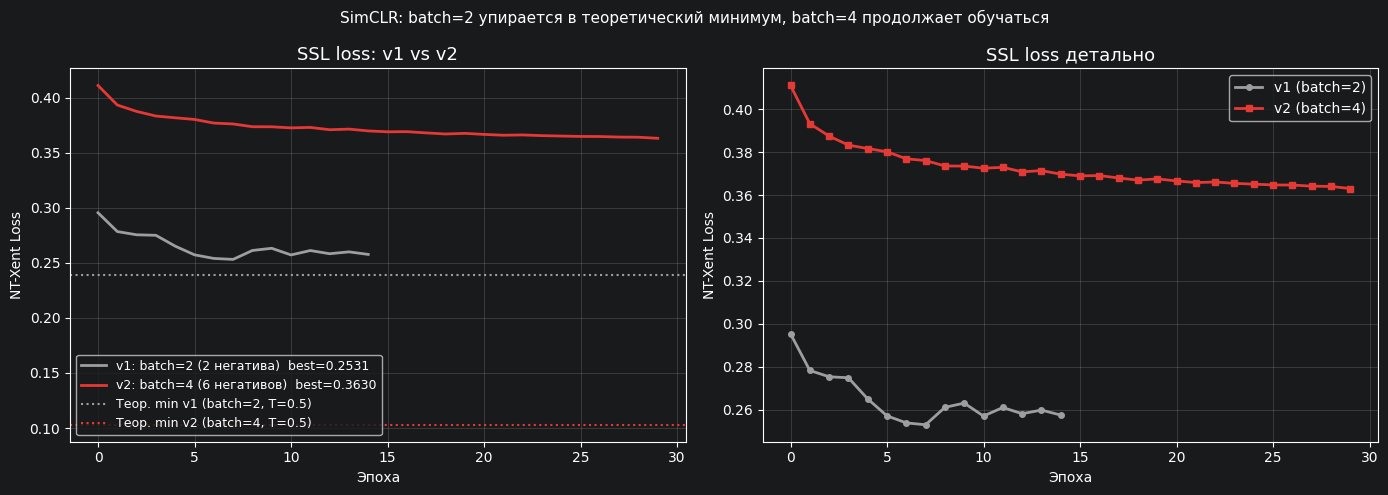

SSL v1: min loss = 0.2531, плато с эп. ~3
SSL v2: min loss = 0.3630
Улучшение loss: -0.1099  (-43.4%)


In [14]:
# Загружаем историю SSL v1
with open(os.path.join(save_dir, 'history_ssl_exp18.json')) as f:
    ssl_hist_v1 = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График сравнения
axes[0].plot(ssl_hist_v1['ssl_loss'], color='#9E9E9E', lw=2,
             label=f'v1: batch=2 (2 негатива)  best={min(ssl_hist_v1["ssl_loss"]):.4f}')
axes[0].plot(ssl_hist_v2['ssl_loss'], color='#E53935', lw=2,
             label=f'v2: batch=4 (6 негативов)  best={min(ssl_hist_v2["ssl_loss"]):.4f}')
axes[0].axhline(y=0.239, color='#9E9E9E', ls=':', lw=1.5,
                label='Теор. min v1 (batch=2, T=0.5)')
axes[0].axhline(y=0.103, color='#E53935', ls=':', lw=1.5,
                label='Теор. min v2 (batch=4, T=0.5)')
axes[0].set_title('SSL loss: v1 vs v2', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('NT-Xent Loss')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

# Где v1 достигло плато vs где v2 продолжает падать
axes[1].plot(ssl_hist_v1['ssl_loss'], color='#9E9E9E', lw=2, marker='o',
             markersize=4, label='v1 (batch=2)')
axes[1].plot(ssl_hist_v2['ssl_loss'], color='#E53935', lw=2, marker='s',
             markersize=4, label='v2 (batch=4)')
axes[1].set_title('SSL loss детально', fontsize=13)
axes[1].set_xlabel('Эпоха'); axes[1].set_ylabel('NT-Xent Loss')
axes[1].legend(fontsize=10); axes[1].grid(True, alpha=0.3)

plt.suptitle('SimCLR: batch=2 упирается в теоретический минимум, batch=4 продолжает обучаться',
             fontsize=11)
plt.tight_layout(); plt.show()

v1_min = min(ssl_hist_v1['ssl_loss'])
v2_min = min(ssl_hist_v2['ssl_loss'])
v1_plateau_ep = next((i for i in range(1, len(ssl_hist_v1['ssl_loss']))
                      if abs(ssl_hist_v1['ssl_loss'][i] -
                             ssl_hist_v1['ssl_loss'][i-1]) < 0.001), 'нет')
print(f'SSL v1: min loss = {v1_min:.4f}, плато с эп. ~{v1_plateau_ep}')
print(f'SSL v2: min loss = {v2_min:.4f}')
print(f'Улучшение loss: {(v1_min - v2_min):.4f}  ({(v1_min-v2_min)/v1_min*100:.1f}%)')

## 13. Fine-tuning (точный пайплайн Эксп.17 с SSL backbone)

In [15]:
def train_finetune_with_ssl(ssl_backbone, train_ids, val_ids, df,
                             synth_pairs=None, n_epochs=EPOCHS,
                             label='ft_exp18v2', checkpoint_every=25):
    """Fine-tuning идентичен Эксп.17, но backbone загружен из SSL."""
    for p in ssl_backbone.parameters(): p.requires_grad = False
    for i in range(n_blocks - N_UNFREEZE, n_blocks):
        for p in ssl_backbone.blocks[i].parameters(): p.requires_grad = True
    for p in ssl_backbone.norm.parameters(): p.requires_grad = True

    head = SegHeadDPT().to(DEVICE)

    bb_groups  = make_backbone_param_groups(ssl_backbone)
    head_group = [{'params': list(head.parameters()),
                   'lr': LR_HEAD, 'weight_decay': 1e-4, 'name': 'head'}]
    opt   = optim.AdamW(bb_groups + head_group)
    sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    scaler = torch.amp.GradScaler('cuda') if USE_AMP else None

    print('Веса классов:')
    cw   = compute_class_weights(train_ids, df)
    cce  = nn.CrossEntropyLoss(weight=cw, reduction='none')
    clov = LovászSoftmax()

    if synth_pairs is not None:
        tds = SteelSegDatasetWithSynth(
            train_ids, TRAIN_IMG_DIR, df, train_jt, synth_pairs)
    else:
        tds = SteelSegDataset(train_ids, TRAIN_IMG_DIR, df, train_jt)
    vds = SteelSegDataset(val_ids, TRAIN_IMG_DIR, df, val_jt)
    tdl = DataLoader(tds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vdl = DataLoader(vds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    iou  = JaccardIndex(task='multiclass', num_classes=NUM_CLASSES,
                        average='none').to(DEVICE)
    hist = {'train_loss': [], 'val_miou': [], 'val_iou_per_class': []}
    best = 0.0
    best_state_head = None
    best_state_bb   = None

    print(f'Обучающих: {len(tds)}  |  Валидационных: {len(vds)}')
    print(f'AMP: {USE_AMP}  |  Batch: {BATCH_SIZE}  |  Батчей/эпоху: {len(tdl)}')

    for ep in range(1, n_epochs + 1):
        ssl_backbone.eval()
        for i in range(n_blocks - N_UNFREEZE, n_blocks):
            ssl_backbone.blocks[i].train()
        ssl_backbone.norm.train()
        head.train()

        tl = 0.0
        for imgs, masks, is_synth in tdl:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            opt.zero_grad()

            if scaler:
                with torch.amp.autocast('cuda'):
                    feats = ssl_backbone.get_intermediate_layers(
                        imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                    lg = head(feats)
                    px_loss = cce(lg, masks)
                    w_batch = torch.where(
                        is_synth.bool().to(DEVICE)[:, None, None],
                        torch.full_like(px_loss, SYNTH_WEIGHT),
                        torch.ones_like(px_loss))
                    loss = (px_loss * w_batch).mean() + clov(lg, masks)
                scaler.scale(loss).backward()
                scaler.step(opt)
                scaler.update()
            else:
                feats = ssl_backbone.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                lg = head(feats)
                px_loss = cce(lg, masks)
                w_batch = torch.where(
                    is_synth.bool().to(DEVICE)[:, None, None],
                    torch.full_like(px_loss, SYNTH_WEIGHT),
                    torch.ones_like(px_loss))
                loss = (px_loss * w_batch).mean() + clov(lg, masks)
                loss.backward()
                opt.step()

            tl += loss.item()
        sched.step()

        ssl_backbone.eval(); head.eval(); iou.reset()
        with torch.no_grad():
            for imgs, masks, _ in vdl:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                if USE_AMP:
                    with torch.amp.autocast('cuda'):
                        feats = ssl_backbone.get_intermediate_layers(
                            imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                        preds = head(feats).argmax(1)
                else:
                    feats = ssl_backbone.get_intermediate_layers(
                        imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                    preds = head(feats).argmax(1)
                iou.update(preds, masks)

        ipc = iou.compute().cpu().numpy()
        mi  = float(ipc.mean())
        hist['train_loss'].append(tl / len(tdl))
        hist['val_miou'].append(mi)
        hist['val_iou_per_class'].append(ipc.tolist())

        if mi > best:
            best = mi
            best_state_head = {k: v.clone() for k, v in head.state_dict().items()}
            best_state_bb   = {k: v.clone() for k, v in ssl_backbone.state_dict().items()}

        if ep % 10 == 0 or ep == 1:
            s = '  '.join([f'cls{i}:{v:.3f}' for i, v in enumerate(ipc)])
            print(f'[{label}] Эп {ep:3d}/{n_epochs} | '
                  f'Loss:{tl/len(tdl):.4f} | mIoU:{mi:.4f} | {s}')

        if ep % checkpoint_every == 0:
            ckpt_path = os.path.join(save_dir, f'ckpt_{label}_ep{ep}.pt')
            torch.save({'epoch': ep, 'head_state': head.state_dict(),
                        'backbone_state': ssl_backbone.state_dict(),
                        'history': hist, 'best_miou': best}, ckpt_path)
            print(f'  Чекпоинт: {ckpt_path}')

    head.load_state_dict(best_state_head)
    ssl_backbone.load_state_dict(best_state_bb)
    print(f'\n  -> Лучший mIoU: {best:.4f}')
    return head, hist


print('Fine-tuning функция определена.')

Fine-tuning функция определена.


## 14. Запуск fine-tuning

In [16]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    free, total = torch.cuda.mem_get_info()
    print(f'VRAM свободно: {free/1e9:.1f} / {total/1e9:.1f} Гб')

print('='*70)
print(f'Эксп.18 v2 — Fine-tuning ({EPOCHS} эпох, пайплайн Эксп.17)')
print(f'  Backbone: SSL-адаптированный (batch={SSL_BATCH_SIZE}, {SSL_EPOCHS} эп.)')
print(f'  Данные: {len(selected_ids)} реал. + {len(synth_pairs)} синт.')
print(f'  Loss: CE(weighted) + Lovász | AMP: {USE_AMP}')
print('='*70)

_ft_t0 = _time.perf_counter()
model_18v2, history_18v2 = train_finetune_with_ssl(
    dinov2_ssl_v2, selected_ids, test_ids, train_df,
    synth_pairs=synth_pairs, label='ft_exp18v2'
)
ft_train_time_sec = _time.perf_counter() - _ft_t0

print(f'\nВремя fine-tuning: {ft_train_time_sec/60:.1f} мин. '
      f'({ft_train_time_sec/EPOCHS:.1f} сек./эпоха)')
print(f'Суммарное время обучения (SSL + FT): '
      f'{(ssl_train_time_sec + ft_train_time_sec)/60:.1f} мин.')

VRAM свободно: 6.3 / 8.5 Гб
Эксп.18 v2 — Fine-tuning (75 эпох, пайплайн Эксп.17)
  Backbone: SSL-адаптированный (batch=4, 30 эп.)
  Данные: 778 реал. + 2269 синт.
  Loss: CE(weighted) + Lovász | AMP: True
Веса классов:
  Фон: 0.100  (301,878,692 пикс.)
  Дефект 1: 1.946  (882,239 пикс.)
  Дефект 2: 2.597  (661,191 пикс.)
  Дефект 3: 0.214  (8,021,328 пикс.)
  Дефект 4: 0.238  (7,225,350 пикс.)
Обучающих: 3047  |  Валидационных: 1334
AMP: True  |  Batch: 4  |  Батчей/эпоху: 762
[ft_exp18v2] Эп   1/75 | Loss:0.4942 | mIoU:0.4436 | cls0:0.949  cls1:0.078  cls2:0.089  cls3:0.497  cls4:0.605
[ft_exp18v2] Эп  10/75 | Loss:0.2897 | mIoU:0.6213 | cls0:0.971  cls1:0.422  cls2:0.405  cls3:0.622  cls4:0.686
[ft_exp18v2] Эп  20/75 | Loss:0.2414 | mIoU:0.6242 | cls0:0.973  cls1:0.461  cls2:0.356  cls3:0.643  cls4:0.689
  Чекпоинт: D:/VKR/VKR/dino_heads\ckpt_ft_exp18v2_ep25.pt
[ft_exp18v2] Эп  30/75 | Loss:0.2129 | mIoU:0.6444 | cls0:0.975  cls1:0.467  cls2:0.418  cls3:0.660  cls4:0.703
[ft_exp18v2]

## 15. Сравнение Эксп.17, Эксп.18 v1, Эксп.18 v2

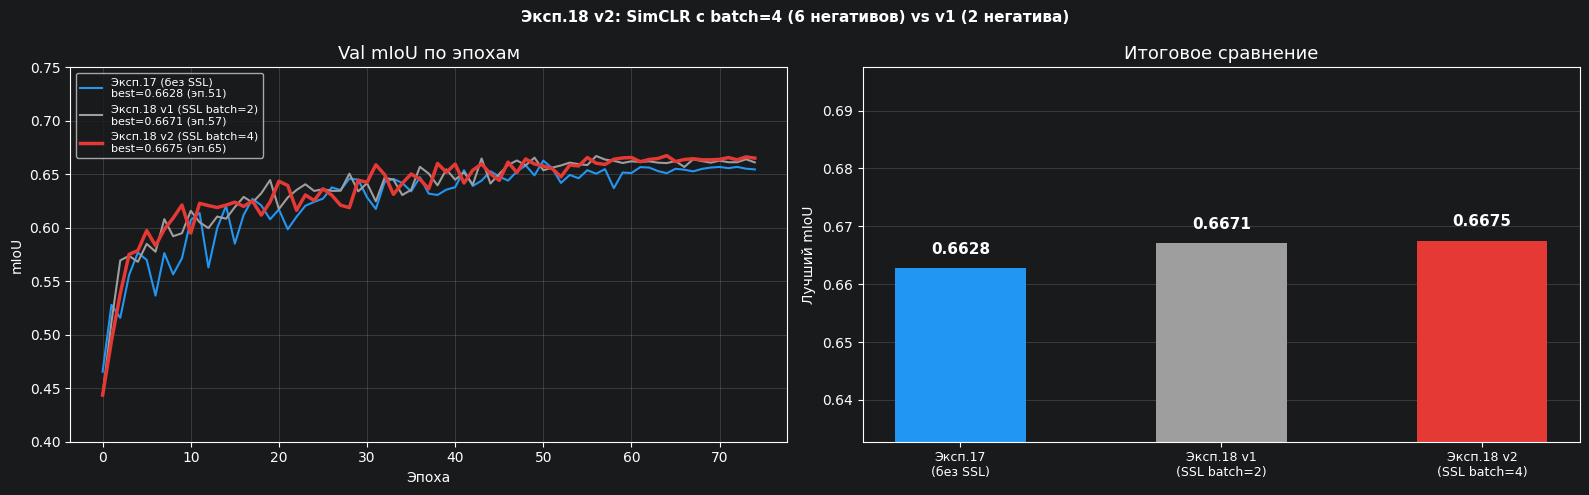


Сводная таблица:
Эксперимент                        mIoU  Δ к Эксп.17
------------------------------------------------------
Эксп.17 (без SSL)                0.6628       +0.00%
Эксп.18 v1 (SSL batch=2)         0.6671       +0.43%
Эксп.18 v2 (SSL batch=4)         0.6675       +0.47%

IoU по классам (лучшая эпоха):
Класс         Эксп.17 (без  Эксп.18 v1 (  Эксп.18 v2 (
------------------------------------------------------
Фон                 0.9766        0.9769        0.9772
Дефект 1            0.5024        0.5043        0.4815
Дефект 2            0.4276        0.4590        0.4625
Дефект 3            0.6733        0.6746        0.6754
Дефект 4            0.7340        0.7206        0.7407


In [17]:
# Загружаем историю предыдущих экспериментов
histories = {}
for name, fname in [
    ('Эксп.17 (без SSL)',          'history_exp17.json'),
    ('Эксп.18 v1 (SSL batch=2)',   'history_exp18.json'),
]:
    p = os.path.join(save_dir, fname)
    if os.path.exists(p):
        with open(p) as f: histories[name] = json.load(f)

histories['Эксп.18 v2 (SSL batch=4)'] = history_18v2

names_ordered = ['Эксп.17 (без SSL)', 'Эксп.18 v1 (SSL batch=2)', 'Эксп.18 v2 (SSL batch=4)']
colors        = ['#2196F3', '#9E9E9E', '#E53935']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Кривые обучения
for name, color in zip(names_ordered, colors):
    if name not in histories: continue
    h   = histories[name]
    mi  = max(h['val_miou'])
    ep  = int(np.argmax(h['val_miou'])) + 1
    lw  = 2.5 if 'v2' in name else 1.5
    axes[0].plot(h['val_miou'], color=color, lw=lw,
                 label=f'{name}\nbest={mi:.4f} (эп.{ep})')

axes[0].set_title('Val mIoU по эпохам', fontsize=13)
axes[0].set_xlabel('Эпоха'); axes[0].set_ylabel('mIoU')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.4, 0.75)

# Bar chart финальных результатов
bar_names = [n for n in names_ordered if n in histories]
bar_vals  = [max(histories[n]['val_miou']) for n in bar_names]
bar_cols  = [c for n, c in zip(names_ordered, colors) if n in histories]

bars = axes[1].bar(range(len(bar_vals)), bar_vals, color=bar_cols, width=0.5, zorder=2)
axes[1].set_xticks(range(len(bar_names)))
axes[1].set_xticklabels([n.replace(' (', '\n(') for n in bar_names], fontsize=9)
axes[1].set_ylabel('Лучший mIoU')
axes[1].set_title('Итоговое сравнение', fontsize=13)
axes[1].set_ylim(min(bar_vals) - 0.03, max(bar_vals) + 0.03)
axes[1].grid(True, axis='y', alpha=0.3, zorder=1)
for bar, val in zip(bars, bar_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.002, f'{val:.4f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('Эксп.18 v2: SimCLR с batch=4 (6 негативов) vs v1 (2 негатива)',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

# Сводная таблица
print('\nСводная таблица:')
print(f'{"Эксперимент":<30} {"mIoU":>8} {"Δ к Эксп.17":>12}')
print('-' * 54)
base = max(histories.get('Эксп.17 (без SSL)', {}).get('val_miou', [0]))
for name in names_ordered:
    if name not in histories: continue
    mi = max(histories[name]['val_miou'])
    delta = f'{(mi-base)*100:+.2f}%' if base > 0 else '—'
    print(f'{name:<30} {mi:>8.4f} {delta:>12}')

# IoU по классам для лучших экспериментов
cls_names = ['Фон', 'Дефект 1', 'Дефект 2', 'Дефект 3', 'Дефект 4']
print('\nIoU по классам (лучшая эпоха):')
print(f'{"Класс":<12}', end='')
for name in names_ordered:
    if name in histories: print(f'{name[:12]:>14}', end='')
print()
print('-' * (12 + 14 * len([n for n in names_ordered if n in histories])))
for c, cname in enumerate(cls_names):
    print(f'{cname:<12}', end='')
    for name in names_ordered:
        if name not in histories: continue
        h  = histories[name]
        ep = int(np.argmax(h['val_miou']))
        print(f'{h["val_iou_per_class"][ep][c]:>14.4f}', end='')
    print()

## 16. Сохранение

In [18]:
torch.save(model_18v2.state_dict(),
           os.path.join(save_dir, 'model_exp18v2.pt'))
torch.save(dinov2_ssl_v2.state_dict(),
           os.path.join(save_dir, 'dinov2_exp18v2.pt'))
with open(os.path.join(save_dir, 'history_exp18v2.json'), 'w') as f:
    json.dump(history_18v2, f)

m_v2 = max(history_18v2['val_miou'])
e_v2 = int(np.argmax(history_18v2['val_miou'])) + 1
i_v2 = history_18v2['val_iou_per_class'][e_v2 - 1]

print('Сохранено:')
print('  model_exp18v2.pt      — голова DPT')
print('  dinov2_exp18v2.pt     — backbone (после SSL v2 + fine-tuning)')
print('  dinov2_ssl_exp18v2.pt — backbone только после SSL v2')
print('  history_exp18v2.json  — история fine-tuning')
print('  history_ssl_exp18v2.json — история SSL')

print(f'\nЛучший mIoU Эксп.18 v2: {m_v2:.4f}  (эпоха {e_v2})')
print(f'IoU по классам: {[f"{v:.3f}" for v in i_v2]}')

base17 = max(histories.get('Эксп.17 (без SSL)', {}).get('val_miou', [0]))
base18v1 = max(histories.get('Эксп.18 v1 (SSL batch=2)', {}).get('val_miou', [0]))
if base17 > 0:
    print(f'\nПрирост vs Эксп.17 (без SSL):       {(m_v2-base17)*100:+.2f}%')
if base18v1 > 0:
    print(f'Прирост vs Эксп.18 v1 (SSL batch=2): {(m_v2-base18v1)*100:+.2f}%')

Сохранено:
  model_exp18v2.pt      — голова DPT
  dinov2_exp18v2.pt     — backbone (после SSL v2 + fine-tuning)
  dinov2_ssl_exp18v2.pt — backbone только после SSL v2
  history_exp18v2.json  — история fine-tuning
  history_ssl_exp18v2.json — история SSL

Лучший mIoU Эксп.18 v2: 0.6675  (эпоха 65)
IoU по классам: ['0.977', '0.481', '0.463', '0.675', '0.741']

Прирост vs Эксп.17 (без SSL):       +0.47%
Прирост vs Эксп.18 v1 (SSL batch=2): +0.04%


## 17. Dice-метрика (на val, сравнение Эксп.17 / Эксп.18 v1 / Эксп.18 v2)

Считаем TP/FP/FN по всей val-выборке (1 334 изображения).  
Формула: $\text{Dice}_c = \frac{2 \cdot TP_c}{2 \cdot TP_c + FP_c + FN_c}$

Считаем Dice для Эксп.18 v2...


Dice 18v2: 100%|██████████| 334/334 [00:49<00:00,  6.75it/s]



══════════════════════════════════════════════════════════════════════════════════
  DICE-МЕТРИКА — СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ
══════════════════════════════════════════════════════════════════════════════════
  Класс                  Эксп.17*   Эксп.18 v1   Эксп.18 v2   Δ v2→v17*
  ──────────────────────────────────────────────────────────────────────────────
  Фон (кл.0)               0.9883       0.9883       0.9885     +0.0001
  Дефект 1 (кл.1)          0.6935       0.6705       0.6500     -0.0435
  Дефект 2 (кл.2)          0.6702       0.6292       0.6325     -0.0377
  Дефект 3 (кл.3)          0.8133       0.8057       0.8063     -0.0070
  Дефект 4 (кл.4)          0.8486       0.8376       0.8511     +0.0025
  ──────────────────────────────────────────────────────────────────────────────
  Mean Dice                0.8028       0.7862       0.7857     -0.0171
══════════════════════════════════════════════════════════════════════════════════
  * Эксп.17: на независимой выборке 5332 из

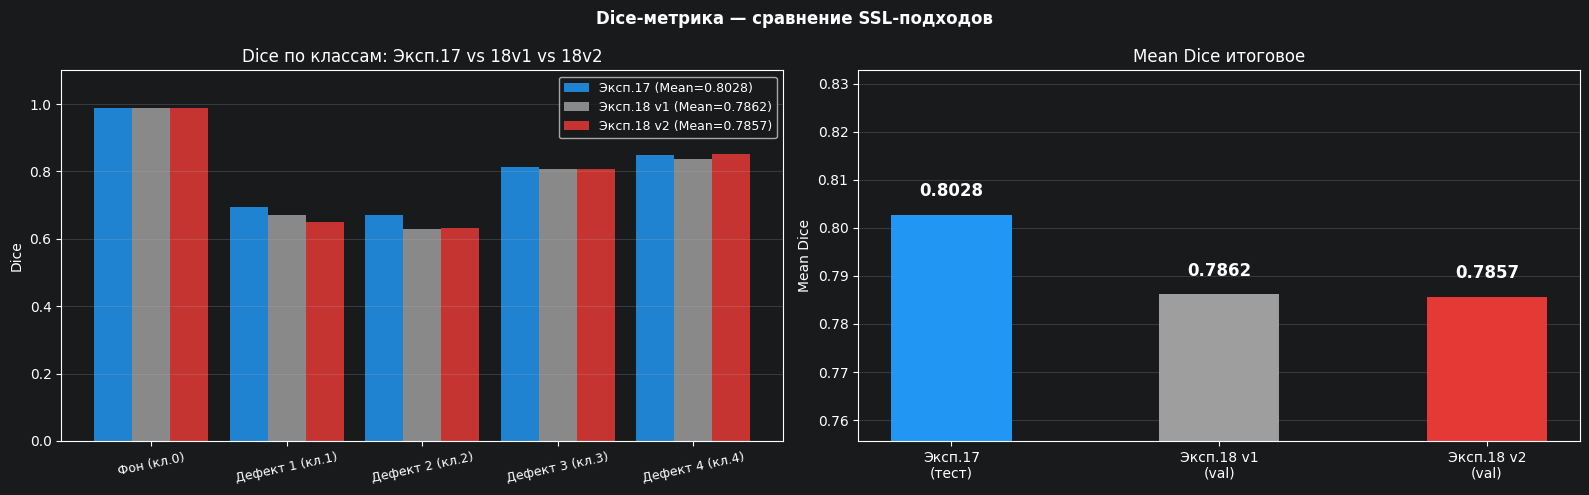

In [19]:
class DiceAccumulator:
    """Накапливает TP/FP/FN побатчево, вычисляет Dice в конце."""
    def __init__(self, num_classes):
        self.num_classes = num_classes
        self.tp = torch.zeros(num_classes)
        self.fp = torch.zeros(num_classes)
        self.fn = torch.zeros(num_classes)

    def update(self, preds: torch.Tensor, targets: torch.Tensor):
        preds   = preds.cpu()
        targets = targets.cpu()
        for c in range(self.num_classes):
            pred_c   = (preds   == c)
            target_c = (targets == c)
            self.tp[c] += ( pred_c &  target_c).sum().float()
            self.fp[c] += ( pred_c & ~target_c).sum().float()
            self.fn[c] += (~pred_c &  target_c).sum().float()

    def compute(self):
        dice = 2 * self.tp / (2 * self.tp + self.fp + self.fn + 1e-8)
        return dice.numpy(), float(dice.mean())


cls_names = ['Фон (кл.0)', 'Дефект 1 (кл.1)', 'Дефект 2 (кл.2)',
             'Дефект 3 (кл.3)', 'Дефект 4 (кл.4)']
cls_colors = ['#95A5A6', '#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

# Создаём dataset для val
val_ds  = SteelSegDataset(test_ids, TRAIN_IMG_DIR, train_df, val_jt)
val_dl  = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# --- Эксп.18 v2 ---
dice_acc_v2 = DiceAccumulator(NUM_CLASSES)
dinov2_ssl_v2.eval(); model_18v2.eval()
print('Считаем Dice для Эксп.18 v2...')
with torch.no_grad():
    for imgs, masks, _ in tqdm(val_dl, desc='Dice 18v2'):
        imgs = imgs.to(DEVICE)
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                feats = dinov2_ssl_v2.get_intermediate_layers(
                    imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
                preds = model_18v2(feats).argmax(1)
        else:
            feats = dinov2_ssl_v2.get_intermediate_layers(
                imgs, n=INTERMEDIATE_LAYERS, return_class_token=False)
            preds = model_18v2(feats).argmax(1)
        dice_acc_v2.update(preds, masks.squeeze())
dice_v2, mean_dice_v2 = dice_acc_v2.compute()

# --- Аналитический Dice из IoU (для сравнения с Эксп.17 независимой выборки) ---
# IoU Эксп.17 на независимой выборке (5332 изобр.) из Test_Experiment17_Independent.ipynb
iou_exp17_test = np.array([0.9769, 0.5308, 0.5040, 0.6853, 0.7370])
dice_exp17_test = 2 * iou_exp17_test / (1 + iou_exp17_test)
mean_dice_exp17_test = float(dice_exp17_test.mean())

# IoU Эксп.18 v1 и v2 на val из history
best_ep_v1 = int(np.argmax(histories.get('Эксп.18 v1 (SSL batch=2)', {}).get('val_miou', [0])))
iou_v1 = np.array(histories.get('Эксп.18 v1 (SSL batch=2)', {}).get(
    'val_iou_per_class', [[0]*5])[best_ep_v1])
dice_v1_anal = 2 * iou_v1 / (1 + iou_v1 + 1e-8)
mean_dice_v1_anal = float(dice_v1_anal.mean())

best_ep_v2 = int(np.argmax(history_18v2['val_miou']))
iou_v2_val = np.array(history_18v2['val_iou_per_class'][best_ep_v2])
dice_v2_anal = 2 * iou_v2_val / (1 + iou_v2_val + 1e-8)
mean_dice_v2_anal = float(dice_v2_anal.mean())

# Печатаем итоговую таблицу
print('\n' + '═'*82)
print('  DICE-МЕТРИКА — СРАВНЕНИЕ ЭКСПЕРИМЕНТОВ')
print('═'*82)
print(f'  {"Класс":<20} {"Эксп.17*":>10} {"Эксп.18 v1":>12} {"Эксп.18 v2":>12}  {"Δ v2→v17*":>10}')
print('  ' + '─'*78)
for i, name in enumerate(cls_names):
    d17 = dice_exp17_test[i]
    d1  = dice_v1_anal[i]
    d2  = dice_v2[i]
    delta = d2 - d17
    print(f'  {name:<20} {d17:>10.4f} {d1:>12.4f} {d2:>12.4f}  {delta:>+10.4f}')
print('  ' + '─'*78)
delta_mean = mean_dice_v2 - mean_dice_exp17_test
print(f'  {"Mean Dice":<20} {mean_dice_exp17_test:>10.4f} '
      f'{mean_dice_v1_anal:>12.4f} {mean_dice_v2:>12.4f}  {delta_mean:>+10.4f}')
print('═'*82)
print('  * Эксп.17: на независимой выборке 5332 изобр. (из Test_Experiment17_DICE.ipynb)')
print('    Эксп.18 v1/v2: на val 1334 изобр. (аналитич. через IoU и прямой подсчёт)')

# График
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
x = np.arange(NUM_CLASSES)
w = 0.28
ax = axes[0]
ax.bar(x - w,   dice_exp17_test, w, label=f'Эксп.17 (Mean={mean_dice_exp17_test:.4f})',
       color='#2196F3', alpha=0.85)
ax.bar(x,       dice_v1_anal,    w, label=f'Эксп.18 v1 (Mean={mean_dice_v1_anal:.4f})',
       color='#9E9E9E', alpha=0.85)
ax.bar(x + w,   dice_v2,         w, label=f'Эксп.18 v2 (Mean={mean_dice_v2:.4f})',
       color='#E53935', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(cls_names, rotation=12, fontsize=9)
ax.set_ylim(0, 1.1); ax.set_ylabel('Dice'); ax.legend(fontsize=9)
ax.set_title('Dice по классам: Эксп.17 vs 18v1 vs 18v2', fontsize=12)
ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
bars2 = ax2.bar(['Эксп.17\n(тест)', 'Эксп.18 v1\n(val)', 'Эксп.18 v2\n(val)'],
                [mean_dice_exp17_test, mean_dice_v1_anal, mean_dice_v2],
                color=['#2196F3', '#9E9E9E', '#E53935'], width=0.45, zorder=2)
ax2.set_ylim(min(mean_dice_exp17_test, mean_dice_v1_anal, mean_dice_v2) - 0.03,
             max(mean_dice_exp17_test, mean_dice_v1_anal, mean_dice_v2) + 0.03)
for bar, val in zip(bars2, [mean_dice_exp17_test, mean_dice_v1_anal, mean_dice_v2]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
             f'{val:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Dice'); ax2.set_title('Mean Dice итоговое', fontsize=12)
ax2.grid(axis='y', alpha=0.3, zorder=1)

plt.suptitle('Dice-метрика — сравнение SSL-подходов', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## 18. Метрики эффективности модели

- Скорость обработки одного изображения (сек., FPS)
- Время обучения (SSL + fine-tuning)
- Потребление VRAM при инференсе (МБ/изображение)
- Память для загрузки весов (МБ)
- Количество параметров

In [20]:
import time as _time2

# ── 1. Параметры модели ───────────────────────────────────────────────
n_bb   = sum(p.numel() for p in dinov2_ssl_v2.parameters()) / 1e6
n_hd   = sum(p.numel() for p in model_18v2.parameters())   / 1e6
n_total = n_bb + n_hd

# ── 2. Размер файлов весов на диске ───────────────────────────────────
head_path_v2 = os.path.join(save_dir, 'model_exp18v2.pt')
bb_path_v2   = os.path.join(save_dir, 'dinov2_exp18v2.pt')
head_mb  = os.path.getsize(head_path_v2) / (1024**2) if os.path.exists(head_path_v2) else 0
bb_mb    = os.path.getsize(bb_path_v2)   / (1024**2) if os.path.exists(bb_path_v2)   else 0
total_mb = head_mb + bb_mb

# ── 3. Скорость инференса и VRAM (одно изображение, среднее по 20 прогонам) ──
sample_img = next(iter(
    DataLoader(SteelSegDataset([test_ids[0]], TRAIN_IMG_DIR, train_df, val_jt),
               batch_size=1)))[0].to(DEVICE)

dinov2_ssl_v2.eval(); model_18v2.eval()

# Прогрев GPU
with torch.no_grad():
    feats = dinov2_ssl_v2.get_intermediate_layers(
        sample_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
    _ = model_18v2(feats)

if DEVICE == 'cuda':
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    mem_before_mb = torch.cuda.memory_allocated() / (1024**2)

times_inf = []
for _ in range(20):
    if DEVICE == 'cuda': torch.cuda.synchronize()
    _t = _time2.perf_counter()
    with torch.no_grad():
        if USE_AMP:
            with torch.amp.autocast('cuda'):
                feats  = dinov2_ssl_v2.get_intermediate_layers(
                    sample_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
                logits = model_18v2(feats)
        else:
            feats  = dinov2_ssl_v2.get_intermediate_layers(
                sample_img, n=INTERMEDIATE_LAYERS, return_class_token=False)
            logits = model_18v2(feats)
    if DEVICE == 'cuda': torch.cuda.synchronize()
    times_inf.append(_time2.perf_counter() - _t)

avg_inf_sec = float(np.mean(times_inf))
std_inf_sec = float(np.std(times_inf))
fps_inf     = 1.0 / avg_inf_sec
vram_inf_mb = 0.0
if DEVICE == 'cuda':
    vram_inf_mb = torch.cuda.max_memory_allocated() / (1024**2) - mem_before_mb

# ── 4. Итоговая сводка ────────────────────────────────────────────────
print('═'*70)
print('  МЕТРИКИ ЭФФЕКТИВНОСТИ — ЭКСПЕРИМЕНТ 18 v2')
print('═'*70)

print('\n  ПАРАМЕТРЫ МОДЕЛИ')
print(f'  {"─"*60}')
print(f'  Backbone  (DINOv2 ViT-B/14):    {n_bb:.1f} млн. параметров')
print(f'  Декодер   (SegHeadDPT):          {n_hd:.2f} млн. параметров')
print(f'  Итого:                           {n_total:.1f} млн. параметров')

print('\n  ПАМЯТЬ')
print(f'  {"─"*60}')
print(f'  Декодер  (model_exp18v2.pt):     {head_mb:.1f} МБ')
print(f'  Backbone (dinov2_exp18v2.pt):    {bb_mb:.1f} МБ')
print(f'  Суммарно:                        {total_mb:.1f} МБ')

print('\n  СКОРОСТЬ ИНФЕРЕНСА  (одно изображение 224×1400)')
print(f'  {"─"*60}')
print(f'  Среднее время:   {avg_inf_sec:.4f} ± {std_inf_sec:.4f} сек.')
print(f'  FPS:             {fps_inf:.2f} изображений/сек.')
print(f'  VRAM на кадр:    {vram_inf_mb:.1f} МБ')

print('\n  ВРЕМЯ ОБУЧЕНИЯ')
print(f'  {"─"*60}')
print(f'  SSL-фаза   ({SSL_EPOCHS} эп., batch={SSL_BATCH_SIZE}):  '
      f'{ssl_train_time_sec/60:.1f} мин.  '
      f'({ssl_train_time_sec/SSL_EPOCHS:.1f} сек./эп.)')
print(f'  Fine-tuning ({EPOCHS} эп., batch={BATCH_SIZE}):  '
      f'{ft_train_time_sec/60:.1f} мин.  '
      f'({ft_train_time_sec/EPOCHS:.1f} сек./эп.)')
print(f'  Суммарно:        '
      f'{(ssl_train_time_sec+ft_train_time_sec)/60:.1f} мин.  '
      f'({(ssl_train_time_sec+ft_train_time_sec)/3600:.2f} ч.)')
print('═'*70)

# ── Сравнение с Эксп.17 ───────────────────────────────────────────────
print('\n  СРАВНЕНИЕ С ЭКСП.17 (из Test_Experiment17_Independent.ipynb)')
print(f'  {"Метрика":<35} {"Эксп.17":>10} {"Эксп.18 v2":>12}')
print('  ' + '─'*60)
ref = {
    'FPS':                       (13.03,  fps_inf),
    'Время на изображение, сек.': (0.0767, avg_inf_sec),
    'VRAM на изображение, МБ':    (71.2,   vram_inf_mb),
    'Размер весов, МБ':           (341.2,  total_mb),
    'Параметров, млн.':           (89.4,   n_total),
}
for metric, (v17, v18) in ref.items():
    delta = v18 - v17
    print(f'  {metric:<35} {v17:>10.2f} {v18:>12.2f}  ({delta:+.2f})')

# ── Сохранение в CSV ──────────────────────────────────────────────────
import pandas as pd
eff_df = pd.DataFrame({
    'Метрика': list(ref.keys()) + ['SSL время обучения, мин.', 'FT время обучения, мин.',
                                    'Суммарное время обучения, мин.'],
    'Эксп.17': [v[0] for v in ref.values()] + [None, None, None],
    'Эксп.18v2': [v[1] for v in ref.values()] + [
        round(ssl_train_time_sec/60, 1),
        round(ft_train_time_sec/60, 1),
        round((ssl_train_time_sec+ft_train_time_sec)/60, 1)
    ]
})
out_eff = os.path.join(save_dir, 'efficiency_exp18v2.csv')
eff_df.to_csv(out_eff, index=False, encoding='utf-8-sig')
print(f'\nТаблица сохранена: {out_eff}')

══════════════════════════════════════════════════════════════════════
  МЕТРИКИ ЭФФЕКТИВНОСТИ — ЭКСПЕРИМЕНТ 18 v2
══════════════════════════════════════════════════════════════════════

  ПАРАМЕТРЫ МОДЕЛИ
  ────────────────────────────────────────────────────────────
  Backbone  (DINOv2 ViT-B/14):    86.6 млн. параметров
  Декодер   (SegHeadDPT):          2.85 млн. параметров
  Итого:                           89.4 млн. параметров

  ПАМЯТЬ
  ────────────────────────────────────────────────────────────
  Декодер  (model_exp18v2.pt):     10.9 МБ
  Backbone (dinov2_exp18v2.pt):    330.3 МБ
  Суммарно:                        341.2 МБ

  СКОРОСТЬ ИНФЕРЕНСА  (одно изображение 224×1400)
  ────────────────────────────────────────────────────────────
  Среднее время:   0.0262 ± 0.0082 сек.
  FPS:             38.22 изображений/сек.
  VRAM на кадр:    102.7 МБ

  ВРЕМЯ ОБУЧЕНИЯ
  ────────────────────────────────────────────────────────────
  SSL-фаза   (30 эп., batch=4):  819.5 мин.  (1638.9 се